# Assignment: Amazon Sales Dataset — EDA, Feature Engineering & Basic Modeling

**Dataset:** [Amazon Sales Dataset on Kaggle](https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset) — file `amazon.csv` (~1,465 rows, 16 columns).

**Total marks:** 100 (+10 bonus) · **Estimated effort:** 8–10 hours

**Instructions**
- Answer every question in the cells provided. Add more cells if you need them.
- Every plot needs a title, labelled axes (with units) and 1–2 sentences of interpretation below it.
- Use `random_state=42` wherever randomness is involved.
- The notebook must run top-to-bottom without errors before submission.
- Disclose any AI-tool use in the final cell.

**Name:** ______ · **Roll no.:** ______

## Setup
Import the libraries you need and list their versions.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Add further imports here (scikit-learn, nltk/textblob, etc.)

## Dataset columns

| Column | Meaning | Raw format / notes |
| --- | --- | --- |
| product_id | Amazon ASIN | String; some IDs repeat |
| product_name | Listing title | Free text |
| category | Category path | Pipe-separated (`\|`) |
| discounted_price | Selling price (₹) | String with `₹` and commas |
| actual_price | List price (₹) | String with `₹` and commas |
| discount_percentage | Discount | String like `64%` |
| rating | Average star rating | String; contains an invalid value |
| rating_count | Number of ratings | String with commas; a few missing |
| about_product | Product description | Free text |
| user_id, user_name | Reviewers | Comma-separated lists |
| review_id, review_title, review_content | Reviews | Comma-separated lists |
| img_link, product_link | URLs | Not needed for modeling |

# Part A — Data loading and cleaning (15 marks)
Produce a clean DataFrame `df_clean` and justify every cleaning decision in a markdown cell.

**A1 (2 marks).** Load `amazon.csv` and report its shape, dtypes, `head()` and memory usage.

In [35]:
df = pd.read_csv('D:/Pine_labs_Assignment/amazon.csv')
df.head()  # Loading dataset

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [36]:
print(f"Shape of the dataset: {df.shape}")  # Checking the shape of the dataset

Shape of the dataset: (1465, 16)


**observation:**
The dataset contains 1465 rows and 16 columns.

In [37]:
df.info() # Checking the information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

**Observation:**  
All 16 features are currently stored as `object` datatype, and the
DataFrame uses approximately 183.3 KB of memory.

**A2 (3 marks).** Convert `discounted_price` and `actual_price` to floats by stripping `₹` and commas. Convert `discount_percentage` to a float between 0 and 1.

In [38]:
df_copy = df.copy()  # Creating a copy of the original dataframe to avoid modifying it directly
df_copy['discounted_price'] = (
    df_copy['discounted_price']
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype(float)
)

df_copy['actual_price'] = (
    df_copy['actual_price']
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype(float)
)

df_copy['discount_percentage'] = (
    df_copy['discount_percentage']
    .str.replace("%", "")
    .astype(float) / 100
)

### Observation

A copy of the original dataset is created to preserve the original data while performing the required cleaning operations.

- **`discounted_price` and `actual_price`**: The `₹` currency symbol and commas are removed using str and replace, and the values are converted from strings to `float`.
- **`discount_percentage`**: The `%` symbol is removed and the values are converted to `float` using str and replace. The values are then divided by 100 to represent the discount as a proportion between 0 and 1.

These transformations convert the relevant variables into numerical formats suitable for further analysis.

**A3 (2 marks).** Convert `rating` to float. Find the invalid value(s) and explain what you did with them (drop, impute or look up) and why.

In [52]:
df_copy['rating'].value_counts()

rating
4.1    244
4.3    230
4.2    228
4.0    181
3.9    123
4.4    123
3.8     87
4.5     75
3.7     42
3.6     35
3.5     26
4.6     17
3.3     16
3.4     10
4.7      6
3.0      4
3.1      4
5.0      3
4.8      3
3.2      2
2.8      2
2.3      1
2.0      1
2.6      1
2.9      1
Name: count, dtype: int64

In [40]:
df_copy['rating'].isnull().sum()  # Checking for missing values in the 'rating' column

np.int64(0)

In [41]:
df_copy[df_copy['rating'] == "|"] # Checking for invalid ratings

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
1279,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",2099.0,2499.0,0.16,|,992,No Installation is provided for this product|1...,"AGTDSNT2FKVYEPDPXAA673AIS44A,AER2XFSWNN4LAUCJ5...","Divya,Dr Nefario,Deekshith,Preeti,Prasanth R,P...","R2KKTKM4M9RDVJ,R1O692MZOBTE79,R2WRSEWL56SOS4,R...","Decent product,doesn't pick up sand,Ok ok,Must...","Does the job well,doesn't work on sand. though...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Eureka-Forbes-Vacuum-Cle...


In [42]:
df_copy.loc[df_copy['rating'] == "|", 'rating'] = 3.8

In [43]:
df_copy['rating'] = df_copy['rating'].astype(float)  # Converting rating to float

**Treatment of the Invalid Value:**  
Since this was the only invalid value in the `rating` column and a product link was available in the dataset, I manually verified the rating on Amazon and used the corresponding value. If multiple such missing or invalid values were present, a more systematic approach based on product category, similar products, or other relevant features would have been more appropriate for imputation.

**A4 (2 marks).** Convert `rating_count` to integer. Report how many values are missing and choose a handling strategy.

In [45]:
df_copy['rating_count'].isna().sum()  # Checking the missing values in the 'rating_count' column

np.int64(2)

In [47]:
df_copy[df_copy['rating_count'].isnull()]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
282,B0B94JPY2N,Amazon Brand - Solimo 65W Fast Charging Braide...,Computers&Accessories|Accessories&Peripherals|...,199.0,999.0,0.80,3.0,NaN,USB C to C Cable: This cable has type C connec...,AE7CFHY23VAJT2FI4NZKKP6GS2UQ,Pranav,RUB7U91HVZ30,The cable works but is not 65W as advertised,I have a pd supported car charger and I bought...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Amazon-Brand-Charging-Su...
324,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories|Accessories&Peripherals|...,249.0,999.0,0.75,5.0,NaN,💎[The Fastest Charge] - This iPhone USB C cabl...,AGJC5O5H5BBXWUV7WRIEIOOR3TVQ,Abdul Gafur,RQXD5SAMMPC6L,Awesome Product,Quick delivery.Awesome ProductPacking was good...,https://m.media-amazon.com/images/I/31-q0xhaTA...,https://www.amazon.in/REDTECH-Lightning-Certif...


In [86]:
df_copy.loc[df_copy['product_id'] =="B0B94JPY2N", "rating_count"] = 63 # Looked up the rating count for the product with product_id "B0B94JPY2N" and found it to be 63, so filling that value in the missing entry.

In [54]:
df_copy[df_copy['rating_count'].isnull()]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
324,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories|Accessories&Peripherals|...,249.0,999.0,0.75,5.0,NaN,💎[The Fastest Charge] - This iPhone USB C cabl...,AGJC5O5H5BBXWUV7WRIEIOOR3TVQ,Abdul Gafur,RQXD5SAMMPC6L,Awesome Product,Quick delivery.Awesome ProductPacking was good...,https://m.media-amazon.com/images/I/31-q0xhaTA...,https://www.amazon.in/REDTECH-Lightning-Certif...


In [64]:
df_copy['rating_count'] = pd.to_numeric(
    df_copy['rating_count'].str.replace(',', '', regex=False),
    errors='coerce'
)

<Axes: xlabel='rating', ylabel='rating_count'>

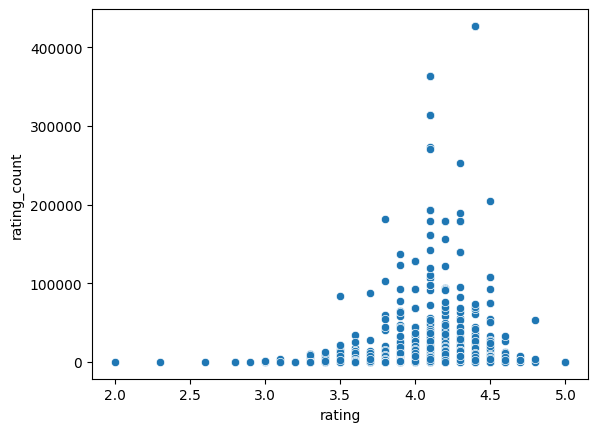

In [73]:
sns.scatterplot(x = df_copy['rating'], y = df_copy['rating_count'])  # Scatter plot of rating vs rating_count

In [84]:
median_value_less_than_4 = df_copy[df_copy["rating"] <= 4]['rating_count'].median()   # Mean rating_count for products with rating <= 4
df_copy.loc[df_copy['product_id'] =="B0BQRJ3C47", "rating_count"] = median_value_less_than_4  # Filling the missing rating_count for product_id "B0BQRJ3C47" with the median value of products with rating <= 4 


In [87]:
df_copy[df_copy['rating_count'].isnull()]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link


In [89]:
df_copy.rating_count.astype(int)  # Converting rating_count to integer type

0       24269
1       43994
2        7928
3       94363
4       16905
        ...  
1460     1090
1461     4118
1462      468
1463     8031
1464     6987
Name: rating_count, Length: 1465, dtype: int64

**Treatment of Missing Values:**  

Since there were only two missing values in the `rating_count` column, I manually verified them using the product links provided in the dataset. For `product_id` `B0B94JPY2N`, the actual rating count was available on Amazon, so I used the verified value directly.

For `product_id` `B0BQRJ3C47`, I used the median rating count of products with a rating below 4. This choice was based on the scatter plot, which indicated that products with ratings below 4 generally had lower rating counts than products rated 4 or above. Therefore, using the median within the lower-rated group provides a more representative imputation than using the overall median.

**A5 (3 marks).** Check for duplicates: full-row duplicates and repeated `product_id`s. Decide which rows to keep and state your rule.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**A6 (2 marks).** Sanity checks: confirm `discounted_price <= actual_price`; recompute the discount from the two prices, compare it with `discount_percentage`, and flag mismatches.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**A7 (1 mark).** Drop columns you will not use and print the final shape of `df_clean`.

In [ ]:
# Your code here


# Part B — Exploratory Data Analysis (25 marks)
Plots without interpretation earn half marks.

## B1. Univariate analysis (7 marks)

**B1.1** Summary statistics for all numeric columns. Comment on mean vs median for prices and `rating_count`.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**B1.2** Histograms of `actual_price`, `discounted_price` and `rating_count` on both linear and log scales. Which scale is more informative, and why?

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**B1.3** Plot the distribution of `rating`. What fraction of products are rated 4.0 or above? What does this imply for a rating-prediction model?

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**B1.4** Plot the distribution of `discount_percentage`.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

## B2. Category analysis (6 marks)

**B2.1** Split `category` on `|` and extract the top-level (`main_category`) and last-level (`sub_category`) labels.

In [ ]:
# Your code here


**B2.2** Bar chart of product counts per `main_category`, and the top 15 sub-categories by count.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**B2.3** Compare median price, median discount and mean rating across main categories. Which category is discounted most heavily?

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

## B3. Bivariate and multivariate analysis (8 marks)

**B3.1** Scatter plot of `discount_percentage` vs `rating`. Do bigger discounts go with better or worse ratings?

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**B3.2** Scatter plot of `log(rating_count)` vs `rating`. Are popular products rated higher?

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**B3.3** Box plots of `rating` by `main_category`.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**B3.4** Correlation heatmaps (Pearson and Spearman) of the numeric columns. Explain any differences between the two.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

## B4. Text and reviewer peek (4 marks)

**B4.1** Count the reviews per row (split `review_id` on commas) and plot the distribution.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**B4.2** Find the most frequent words in `review_title` for products rated ≥ 4.3 vs < 3.8 (after removing stop words). What differs?

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

## B5. Key insights
List **five key insights** from Part B, each backed by a number from your analysis.

1. 
2. 
3. 
4. 
5.

# Part C — Feature engineering (25 marks)
Build a feature matrix `X` for predicting `rating`. Create **at least 10 new features**, with at least one from each group (price, popularity, category, text).

**C1. Price features.** Suggested: `discount_amount`, `log_actual_price`, `log_discounted_price`, `price_bucket` (quantile bins).

In [ ]:
# Your code here


**C2. Popularity features.** Suggested: `log_rating_count`, `is_popular` (above 75th percentile), `rating_count_rank_in_category`.

In [ ]:
# Your code here


**C3. Category features.** Suggested: `main_category`, `sub_category`, `category_depth`; group sub-categories with fewer than 10 products into `Other`.

In [ ]:
# Your code here


**C4. Text features.** Suggested: `name_length`, `about_length`, `n_reviews`, `review_sentiment`, keyword flags from `product_name` (e.g. `is_cable`, `is_wireless`).

In [ ]:
# Your code here


**C5. Feature table.** Fill in one row per new feature.

| Feature | Formula / how computed | Why it might help |
| --- | --- | --- |
|  |  |  |

**C6. Encoding and scaling.** One-hot encode low-cardinality categoricals and justify your approach for high-cardinality ones. Build a `Pipeline` / `ColumnTransformer` so all scaling and encoding is fit on training data only.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**C7. Leakage discussion (4 marks).** Review text and `rating_count` come from the same customers whose ratings you are predicting. Argue whether each is a fair input for a model meant to estimate the rating of a *new* listing. (You will compare models with and without review-derived features in Part D.)

**Your answer:**

_Write here._

# Part D — Basic modeling (25 marks)
Use an 80/20 train–test split (`random_state=42`, stratified for classification) and 5-fold cross-validation on the training set.

**D0.** Create the train–test split.

In [ ]:
# Your code here


## D1. Regression: predict `rating` (12 marks)

**D1.1** Baseline: always predict the training-set mean rating. Report MAE and RMSE.

In [ ]:
# Your code here


**D1.2** Train Linear Regression, Ridge and Random Forest Regressor.

In [ ]:
# Your code here


**D1.3** Report MAE, RMSE and R² on the test set in one comparison table. Does any model beat the baseline meaningfully?

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**D1.4** Plot predicted vs actual ratings and the residuals for your best model.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**D1.5** Retrain your best model **without** review-derived features and report the difference (links to C7).

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

## D2. Classification: predict `high_rated` (10 marks)

**D2.1** Define `high_rated = 1 if rating >= 4.2 else 0` (or justify a different threshold). Report the class balance.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**D2.2** Baseline: majority-class classifier.

In [ ]:
# Your code here


**D2.3** Train Logistic Regression and Random Forest Classifier (or Decision Tree).

In [ ]:
# Your code here


**D2.4** Report accuracy, precision, recall, F1 and ROC-AUC; show the confusion matrix and ROC curve. Why is accuracy alone misleading here?

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

## D3. Interpretation (3 marks)

**D3.1** Show the top 10 features by Random Forest (or permutation) importance and the largest logistic-regression coefficients. Do they match what you expected from Part B?

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

**D4 (optional).** Tune one model with `GridSearchCV` (≤ 20 combinations) and report the gain over defaults.

In [ ]:
# Your code here


**Your answer:**

_Write your interpretation here._

# Part E — Written summary (10 marks)
Write a summary (max 400 words) for a category manager with no data-science background, covering:
1. The three most useful findings about pricing, discounts and ratings, with numbers.
2. How well rating can be predicted compared with the naive baseline, in plain words.
3. Two limitations of the dataset and one extra data source you would ask for.

Also submit this as `summary.pdf`.

**Your summary:**

_Write here._

# Bonus (pick any, max 10 marks)
- **Clustering (5):** K-Means on scaled price, discount and popularity features; profile each cluster in one line.
- **TF-IDF model (5):** Predict `high_rated` from `review_content` with TF-IDF + Logistic Regression; list the 15 most positive and negative terms.
- **Discount model (5):** Predict `discount_percentage` from category, price and popularity. What drives deep discounts?
- **Dashboard (5):** A small interactive Plotly or Streamlit view of category-level metrics.

In [ ]:
# Bonus work here


# AI-use disclosure
Describe any AI tools you used and for what.

_Write here._